<a href="https://colab.research.google.com/github/N1khil-J4dhav/AML-Experiments/blob/main/AML_Experiment_6_Nikhil_Jadhav_35.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Dataset Sample ---
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

--- Model Performance ---
Accuracy: 0.99

--- Confusion Matrix ---


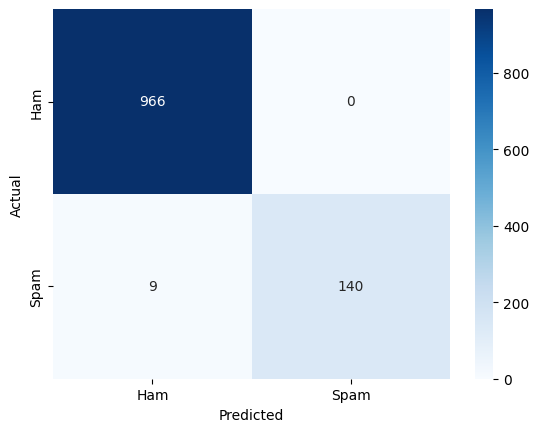


--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       966
           1       1.00      0.94      0.97       149

    accuracy                           0.99      1115
   macro avg       1.00      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115


--- Custom Test ---
Message: WINNER! You have won a 1000 dollar cash prize. Call now to claim!
Result: SPAM


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Load the Dataset
# This is a reliable mirror of the UCI SMS Spam Collection
url = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'
df = pd.read_table(url, header=None, names=['label', 'message'])

print("--- Dataset Sample ---")
print(df.head())

# 2. Preprocessing
# Convert labels to numbers: ham = 0, spam = 1
df['label_num'] = df.label.map({'ham': 0, 'spam': 1})

X = df.message
y = df.label_num

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Extraction (Vectorization)
# We need to turn words into numbers for the model to process them
vect = CountVectorizer()
X_train_dtm = vect.fit_transform(X_train)
X_test_dtm = vect.transform(X_test)

# 5. Build and Train the Naive Bayes Model
# MultinomialNB is the "gold standard" for text classification
nb = MultinomialNB()
nb.fit(X_train_dtm, y_train)

# 6. Make Predictions
y_pred = nb.predict(X_test_dtm)

# 7. Evaluate Performance
print("\n--- Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

# 8. Test with your own message
def predict_spam(new_message):
    new_message_dtm = vect.transform([new_message])
    prediction = nb.predict(new_message_dtm)
    return "SPAM" if prediction[0] == 1 else "HAM (Clean)"

print("\n--- Custom Test ---")
test_msg = "WINNER! You have won a 1000 dollar cash prize. Call now to claim!"
print(f"Message: {test_msg}")
print(f"Result: {predict_spam(test_msg)}")